In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
emp =pd.read_csv("C:\\Users\\Nyla Majid\\OneDrive\\Documents\\Datasets\\employees_dataset.csv", encoding='latin1')
emp.head()


,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


In [3]:
emp.shape

(17417, 13)

In [4]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17417 entries, 0 to 17416
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   employee_id            17417 non-null  int64  
 1   department             17417 non-null  object 
 2   region                 17417 non-null  object 
 3   education              16646 non-null  object 
 4   gender                 17417 non-null  object 
 5   recruitment_channel    17417 non-null  object 
 6   no_of_trainings        17417 non-null  int64  
 7   age                    17417 non-null  int64  
 8   previous_year_rating   16054 non-null  float64
 9   length_of_service      17417 non-null  int64  
 10  KPIs_met_more_than_80  17417 non-null  int64  
 11  awards_won             17417 non-null  int64  
 12  avg_training_score     17417 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 1.7+ MB


In [5]:
emp.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
count,17417.000000,17417.000000,17417.000000,16054.000000,17417.000000,17417.000000,17417.000000,17417.000000
mean,39083.491129,1.250732,34.807774,3.345459,5.801860,0.358845,0.023368,63.176322
std,22707.024087,0.595692,7.694046,1.265386,4.175533,0.479675,0.151074,13.418179
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000
25%,19281.000000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000
50%,39122.000000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000
75%,58838.000000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,75.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,1.000000,99.000000


In [6]:
emp.isnull().sum()

employee_id                 0
department                  0
region                      0
education                 771
gender                      0
recruitment_channel         0
no_of_trainings             0
age                         0
previous_year_rating     1363
length_of_service           0
KPIs_met_more_than_80       0
awards_won                  0
avg_training_score          0
dtype: int64

In [7]:
#handling missing values 
#Education  
emp['education']=emp['education'].fillna('Unknown')

In [8]:
emp['previous_year_rating']= emp['previous_year_rating'].fillna('0')

In [9]:
emp.isnull().sum()

employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
dtype: int64

 ## Generate descriptive statistics and visualisations to understand patterns in employee performance, retention, and demographics. 

In [10]:
#deptartment-wise employee count
emp['department'].value_counts()

department
Sales & Marketing    5458
Operations           3524
Procurement          2240
Technology           2199
Analytics            1697
HR                    833
Finance               802
Legal                 332
R&D                   332
Name: count, dtype: int64

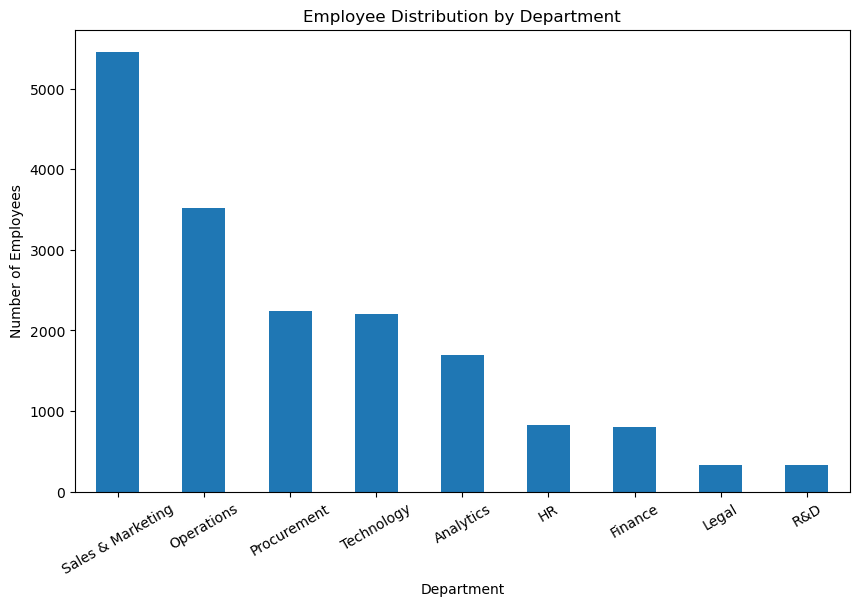

In [11]:
emp['department'].value_counts().plot(kind='bar', figsize=(10,6))
plt.title('Employee Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=30)
plt.show()


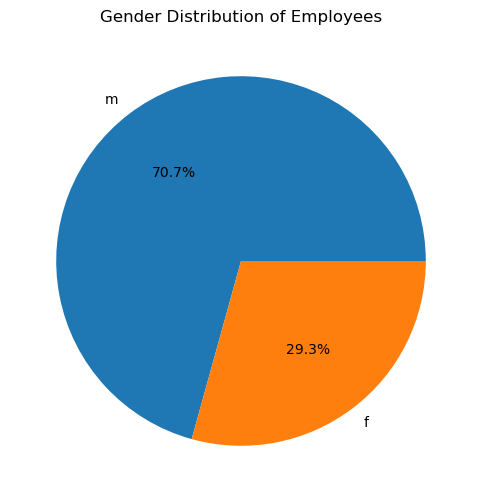

In [12]:
#Gender distribution
emp['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Gender Distribution of Employees')
plt.ylabel('')
plt.show()


In [13]:
emp['gender'].value_counts()

gender
m    12314
f     5103
Name: count, dtype: int64

In [14]:
emp['education'].value_counts()

education
Bachelors          11519
Masters & above     4841
Unknown              771
Below Secondary      286
Name: count, dtype: int64

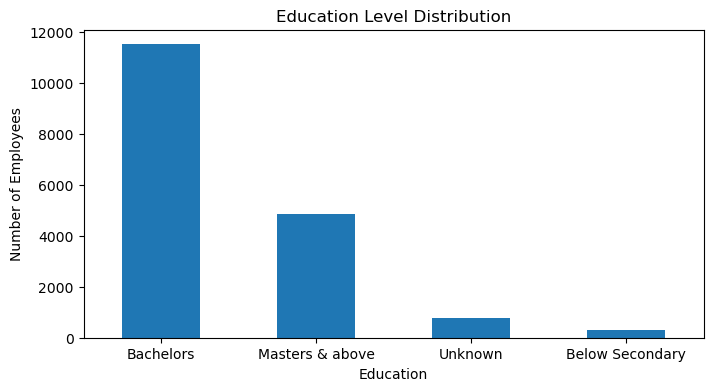

In [15]:
emp['education'].value_counts().plot(kind ='bar',figsize=(8,4) )
plt.title('Education Level Distribution')
plt.xlabel('Education')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.show()

In [16]:
emp['recruitment_channel'].value_counts()

recruitment_channel
other       9751
sourcing    7349
referred     317
Name: count, dtype: int64

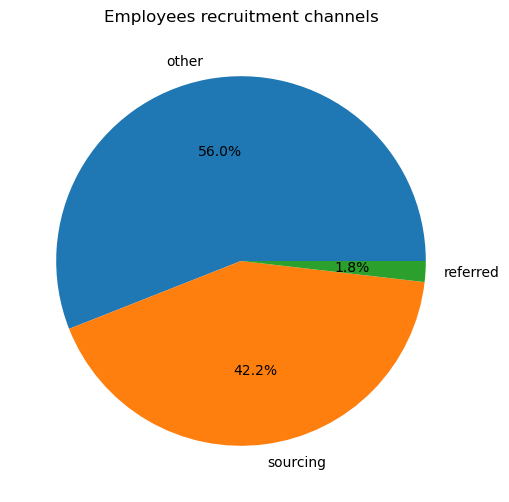

In [17]:
emp['recruitment_channel'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title( 'Employees recruitment channels')
plt.ylabel('')
plt.show()


# Performance Analysis

# KPI Achievement Analysis

In [18]:
emp['KPIs_met_more_than_80'].value_counts()


KPIs_met_more_than_80
0    11167
1     6250
Name: count, dtype: int64

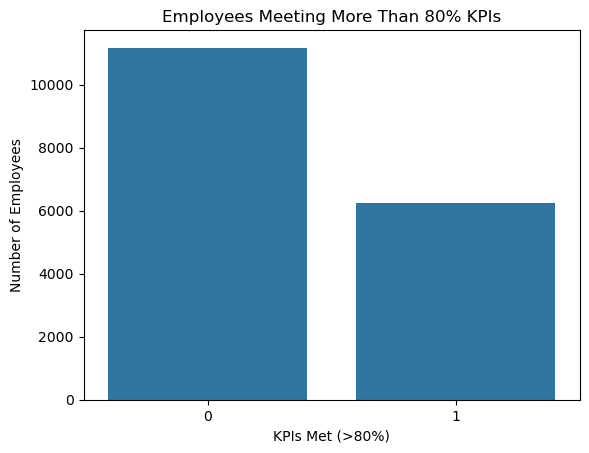

In [19]:
sns.countplot(x='KPIs_met_more_than_80', data=emp)
plt.title('Employees Meeting More Than 80% KPIs')
plt.xlabel('KPIs Met (>80%)')
plt.ylabel('Number of Employees')
plt.show()


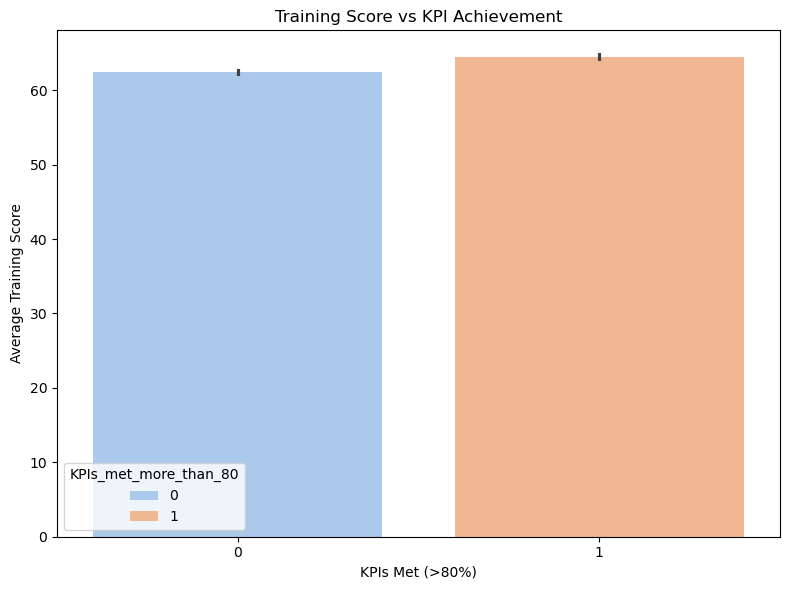

In [20]:
# Training Score vs KPI Achievement
plt.figure(figsize=(8,6))
sns.barplot( x='KPIs_met_more_than_80', y='avg_training_score',data=emp,hue='KPIs_met_more_than_80',palette='pastel')
plt.title('Training Score vs KPI Achievement')
plt.xlabel('KPIs Met (>80%)')
plt.ylabel('Average Training Score')
plt.tight_layout()
plt.show()


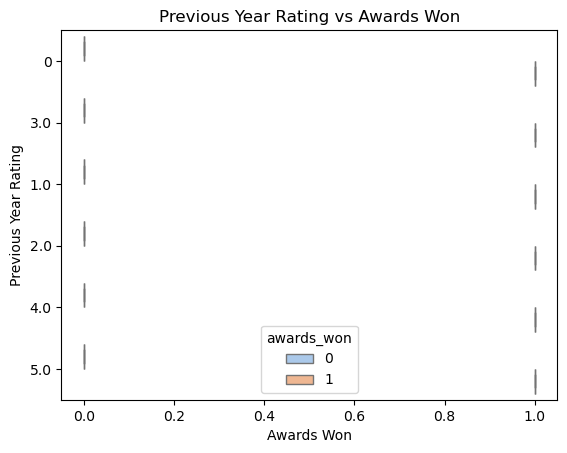

In [21]:
# Awards vs Performance Rating

sns.boxplot(
    x='awards_won',
    y='previous_year_rating',
    data=emp,hue='awards_won',palette='pastel'
)
plt.title('Previous Year Rating vs Awards Won')
plt.xlabel('Awards Won')
plt.ylabel('Previous Year Rating')
plt.show()


# Retention Analysis (Length of Service)

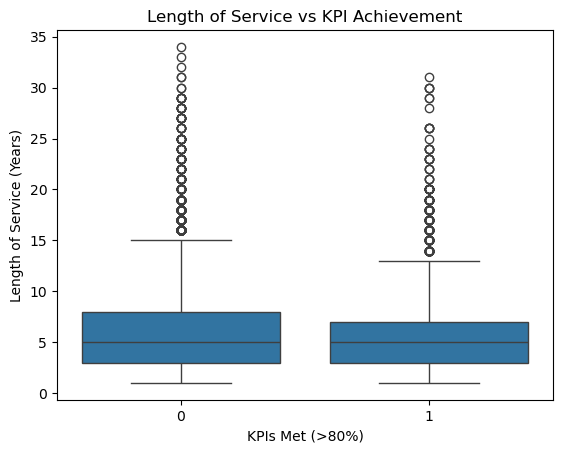

In [22]:
# Length of Service Distribution by KPI
sns.boxplot(
    x='KPIs_met_more_than_80',
    y='length_of_service',
    data=emp
)
plt.title('Length of Service vs KPI Achievement')
plt.xlabel('KPIs Met (>80%)')
plt.ylabel('Length of Service (Years)')
plt.show()


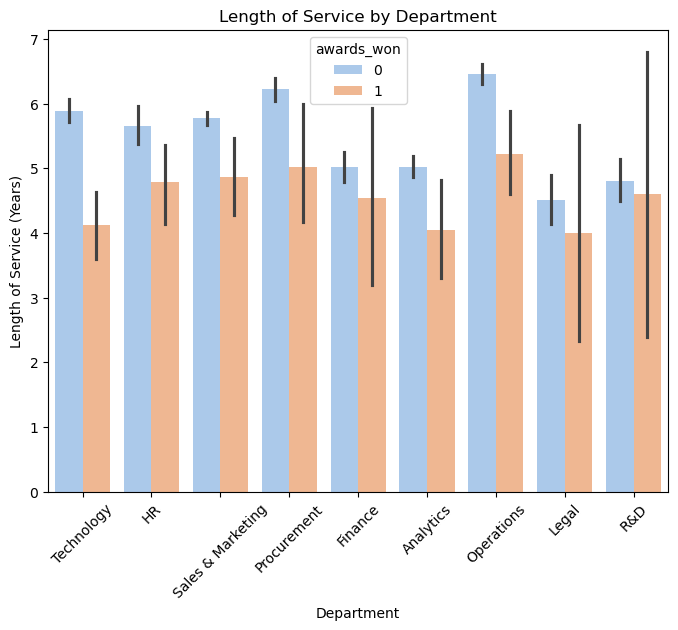

In [23]:
# Department-wise Retention
plt.figure(figsize=(8,6))
sns.barplot(x='department',y='length_of_service',data=emp,hue='awards_won',palette='pastel')
plt.xticks(rotation=45)
plt.title('Length of Service by Department')
plt.xlabel('Department')
plt.ylabel('Length of Service (Years)')
plt.show()


In [24]:
emp.to_csv('C:/Users/Nyla Majid/OneDrive/Documents/Datasets/employees_cleaned.csv', index=False)
emp.isnull().sum()


employee_id              0
department               0
region                   0
education                0
gender                   0
recruitment_channel      0
no_of_trainings          0
age                      0
previous_year_rating     0
length_of_service        0
KPIs_met_more_than_80    0
awards_won               0
avg_training_score       0
dtype: int64

In [27]:
num_cols = emp[['age','previous_year_rating','length_of_service',
               'avg_training_score','no_of_trainings',
               'KPIs_met_more_than_80']]
corr_matrix = num_cols.corr()
corr_matrix

,age,previous_year_rating,length_of_service,avg_training_score,no_of_trainings,KPIs_met_more_than_80
age,1.000000,0.194504,0.641126,-0.028045,-0.085710,-0.025368
previous_year_rating,0.194504,1.000000,0.205194,0.046886,-0.061769,0.264049
length_of_service,0.641126,0.205194,1.000000,-0.026420,-0.061213,-0.079599
avg_training_score,-0.028045,0.046886,-0.026420,1.000000,0.045249,0.071947
no_of_trainings,-0.085710,-0.061769,-0.061213,0.045249,1.000000,-0.045027
KPIs_met_more_than_80,-0.025368,0.264049,-0.079599,0.071947,-0.045027,1.000000


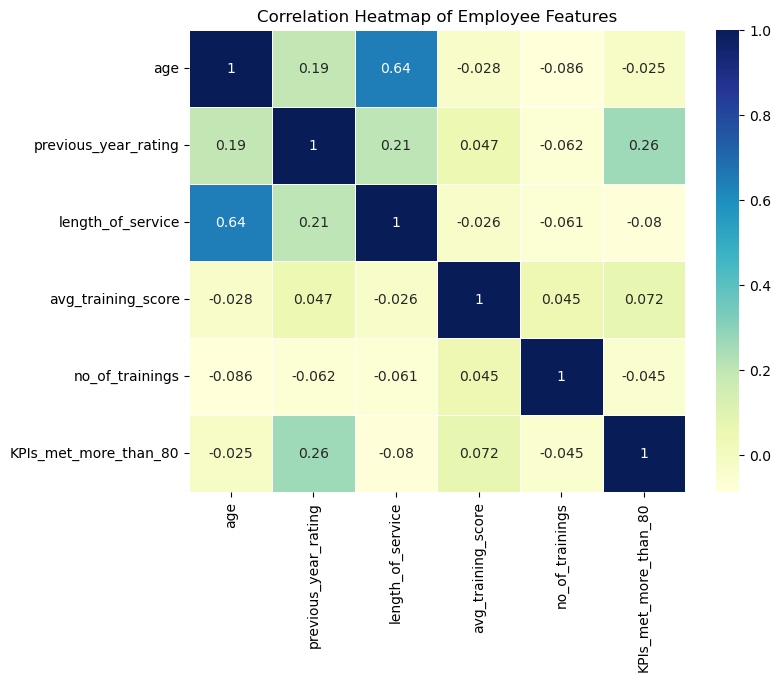

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='YlGnBu',
            linewidths=0.5)

plt.title("Correlation Heatmap of Employee Features")
plt.show()

# Previous year rating shows a positive correlation with KPI achievement, indicating employees with higher past performance tend to meet KPIs.

# Average training score also has a moderate positive relationship with KPI performance, suggesting training effectiveness.

# Age and length of service are positively correlated, which is expected as tenure increases with age.

In [30]:
#Save the figure
plt.savefig('figure.png', format='png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>